## Question

In [10]:
# Can I explain the algorithm?
# Why did I choose this model?
# How was the data preprocessed?
# What evaluation metrics did I use?
# What are the limitations?
# How can I improve it?

In [11]:
import pandas as pd

In [3]:
df = pd.read_csv('Housing.csv')

In [4]:
df.shape

(545, 13)

In [5]:
df = df.drop_duplicates()

In [6]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

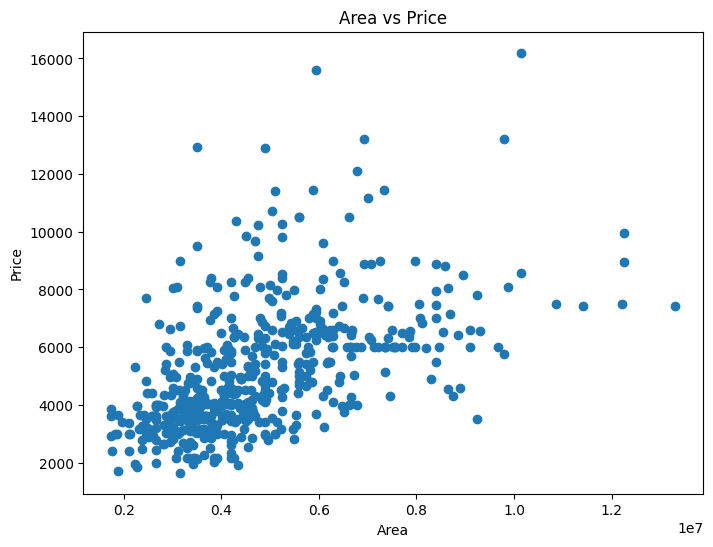

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df["price"], df["area"])

plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Area vs Price")

plt.show()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [9]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

clean_df  = df[(df['price'] >= lower) & (df['price'] <= upper)]
clean_df.shape

(530, 13)

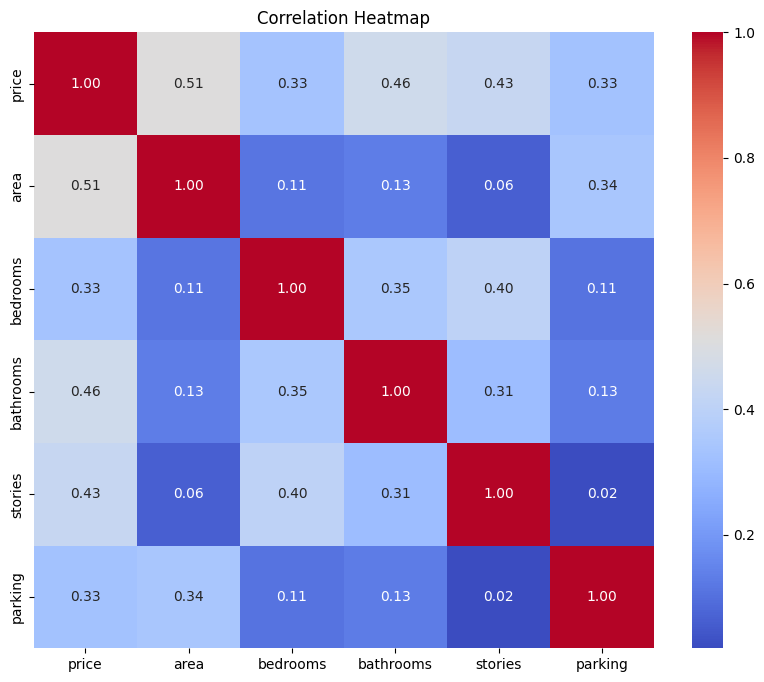

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(
    clean_df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [40]:
categorical = clean_df.select_dtypes('object').columns

In [41]:
encoded = pd.get_dummies(clean_df, columns=categorical, dtype=int, drop_first=True)

In [42]:
encoded.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
15,9100000,6000,4,1,2,2,1,0,1,0,0,0,1,0
16,9100000,6600,4,2,2,1,1,1,1,0,1,1,0,1
17,8960000,8500,3,2,4,2,1,0,0,0,1,0,0,0
18,8890000,4600,3,2,2,2,1,1,0,0,1,0,0,0
19,8855000,6420,3,2,2,1,1,0,0,0,1,1,1,0


In [43]:
X = encoded.drop('price', axis=1)
y = encoded['price']

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)

In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

lr = LinearRegression()
lr.fit(X_train_scale, y_train)
y_pred = lr.predict(X_test_scale)
y_pred_train = lr.predict(X_train_scale)

print('mse train',mean_squared_error(y_train, y_pred_train))
print('rmse train ',root_mean_squared_error(y_train, y_pred_train))

print('---'*40)
print('mse',mean_squared_error(y_test, y_pred))
print('rmse',root_mean_squared_error(y_test, y_pred))
print('mse',mean_absolute_error(y_test, y_pred))
print('r2',r2_score(y_test, y_pred))


mse train 787264870865.9994
rmse train  887279.4773159128
------------------------------------------------------------------------------------------------------------------------
mse 1148203524699.7468
rmse 1071542.5911739331
mse 784877.2641074935
r2 0.668400358283336


In [47]:
from sklearn.linear_model import Ridge

lasso = Ridge(alpha=0.9)
lasso.fit(X_train_scale, y_train)

y_pred = lasso.predict(X_test_scale)

y_pred_train = lasso.predict(X_train_scale)
print('mse train',mean_squared_error(y_train, y_pred_train))
print('rmse train ',root_mean_squared_error(y_train, y_pred_train))

print('---'*40)
print('mse',mean_squared_error(y_test, y_pred))
print('rmse',root_mean_squared_error(y_test, y_pred))
print('mae',mean_absolute_error(y_test, y_pred))
print('r2',r2_score(y_test, y_pred))

mse train 787266992117.6494
rmse train  887280.6726834803
------------------------------------------------------------------------------------------------------------------------
mse 1148895435910.7668
rmse 1071865.400090313
mae 785092.7090996837
r2 0.6682005352513226


In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor()
param_grid =[{
    'n_estimators':[101,151,201],
    'max_depth':[4,5,None],
    'min_samples_split':[2,4,8,6]
}]
grid = GridSearchCV(rf, param_grid=param_grid, cv=5,scoring='neg_mean_squared_error')
grid.fit(X_train_scale, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'max_depth': [4, 5, ...], 'min_samples_split': [2, 4, ...], 'n_estimators': [101, 151, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: in

In [49]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 6, 'n_estimators': 201}


In [50]:
y_pred = grid.predict(X_test_scale)

print('mse',mean_squared_error(y_test, y_pred))
print('rmse',root_mean_squared_error(y_test, y_pred))
print('mae',mean_absolute_error(y_test, y_pred))
print('r2',r2_score(y_test, y_pred))

mse 1245762362966.3674
rmse 1116137.2509536485
mae 843472.9389170938
r2 0.6402254963188904
